# Across stations: the combined views

Every station group you met in notebook 02 also lives in a **dense panel**:
one array per variable with dims `(station, time)` and the station metadata —
`latitude`, `longitude`, `sampling_height` — as coordinates on the `station`
dimension. That turns "compare stations" from a loop over groups into plain
xarray indexing, and it stays **lazy**: selecting three stations pulls three
rows of chunks, not the whole panel.

ObsPack's panels are the top-level views named after each gas (`co2`, `ch4`,
…); FLUXNET stacks its 42 sites in `_combined/<aggregation>`.

In [1]:
import numpy as np, pandas as pd, xarray as xr

panel = xr.open_zarr("https://zarr.icos-cp.eu/icos-obspack.zarr/co2",
                     consolidated=True, chunks={})   # dask-backed: fully lazy
print(dict(panel.sizes))
print("stations:", panel.sizes["station"], "| coords on station:",
      [c for c in ("latitude", "longitude", "sampling_height") if c in panel])

{'station': 162, 'time_co2': 478716, 'dim_concerns': 6}
stations: 162 | coords on station: ['latitude', 'longitude', 'sampling_height']


In [2]:
# Pick stations BY GEOGRAPHY — the coords make the panel queryable.
lat = panel["latitude"].values
ids = np.asarray([s if isinstance(s, str) else s.decode()
                  for s in panel["station"].values])
print("north of 65°N:", sorted(ids[lat > 65]))
print("south of 30°N:", sorted(ids[lat < 30]))

north of 65°N: [np.str_('PAL12'), np.str_('SNO20'), np.str_('SNO50'), np.str_('SNO85'), np.str_('TIK10'), np.str_('ZEP15')]
south of 30°N: [np.str_('IZO29'), np.str_('RUN6')]


(A note for zarr-python **2** users: that version silently fill-values
any chunk whose fetch fails, so a big concurrent `.load()` on a weak link can
fake data gaps — cap the concurrency with
`fsspec.config.conf["gather_batch_size"] = 16`. zarr-python 3, which these
notebooks target, raises on failed fetches instead.)

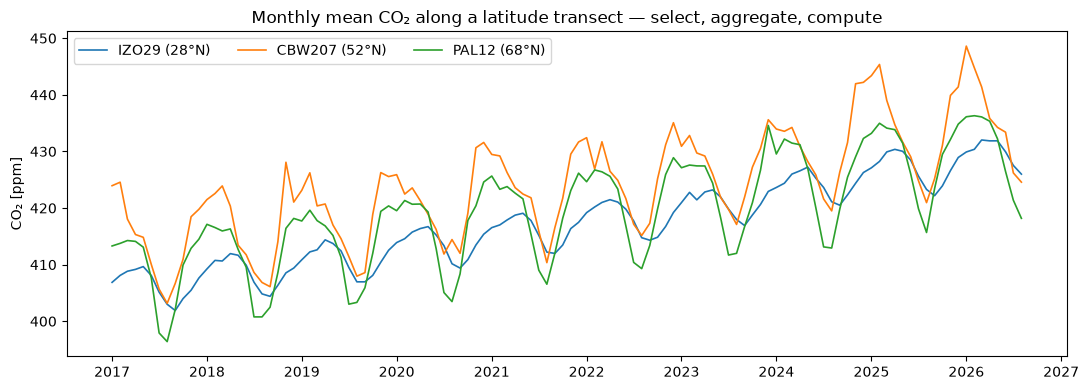

In [3]:
import matplotlib.pyplot as plt

# A latitude transect — three towers from the subtropics to the Arctic.
# Select FIRST (stations + time window), aggregate lazily with dask, and only
# then .compute(): nothing outside 2017+ is ever fetched, and only the monthly
# means materialise in memory. Ending an expression with an explicit
# .compute() is the habit to build — upcoming xarray releases require it for
# dask-backed data.
pick = ["IZO29", "CBW207", "PAL12"]
monthly = (panel["co2"]
           .sel(station=pick, time_co2=slice("2017-01-01", None))
           .resample(time_co2="MS").mean()
           .compute())

fig, ax = plt.subplots(figsize=(11, 4))
for sid in pick:
    lat_s = float(panel["latitude"].sel(station=sid))
    ax.plot(monthly["time_co2"], monthly.sel(station=sid), lw=1.2,
            label=f"{sid} ({lat_s:.0f}°N)")
ax.set_ylabel("CO₂ [ppm]")
ax.set_title("Monthly mean CO₂ along a latitude transect — select, aggregate, compute")
ax.legend(ncols=3)
fig.tight_layout()

The seasonal amplitude grows from the subtropical marine background
(IZO) into the northern mid-latitudes, where the land biosphere's summer
drawdown is strongest, and shrinks again toward the pole; the multi-year rise
is shared by all three. (Cabauw's extra spikes are regional sources around a
200 m tower in NW Europe, not seasonality.) The classic transect, three
chunk-reads deep — and the same panel powers the REST route:
`station=IZO29,CBW207,PAL12` in one `/query` call returns exactly these
series with a passport.

## FLUXNET: rank all 42 sites in one expression

`_combined/fluxnet_mm` stacks every site's monthly cubes. The reference slice
(notebook 04) across the `station` dimension makes cross-site questions
one-liners. Remember the QC rule from notebook 04: the quality fraction lives
on **NEE** — GPP is partitioned from it and has no flags of its own. Here,
the strongest summer photosynthesis across the network:

In [4]:
fx = xr.open_zarr("https://zarr.icos-cp.eu/icos-fluxnet.zarr/_combined/fluxnet_mm",
                  consolidated=True)
good = fx["NEE_QC"].sel(ustar_threshold="VUT", nee_variant="REF") > 0.3
gpp  = (fx["GPP"].sel(partition_method="NT", ustar_threshold="VUT",
                      nee_variant="REF")
        .where(good))
summer = gpp.sel(time=gpp["time"].dt.month.isin([6, 7, 8]))   # JJA only
rank = summer.mean("time").to_series().dropna().sort_values(ascending=False)
print("strongest summer photosynthesis (mean JJA GPP, µmol m⁻² s⁻¹):")
print(rank.head(5).round(1).to_string())

strongest summer photosynthesis (mean JJA GPP, µmol m⁻² s⁻¹):
station
IT-BCi    14.1
DE-HoH    13.2
DK-Sor    12.9
FR-Hes    12.5
CZ-Lnz    12.4


In [5]:
# The session passport covers exactly the panels/chunks these cells read:
import requests
for store in ("icos-obspack.zarr", "icos-fluxnet.zarr"):
    r = requests.get(f"https://zarr.icos-cp.eu/{store}/session/passport").json()
    rec = r["passport"]["@graph"][1]
    print(store, "→", rec["accessedGroups"], rec["dateAccessed"])

icos-obspack.zarr → ['co2'] 2026-08-17T17:14:50Z
icos-fluxnet.zarr → ['_combined/fluxnet_mm'] 2026-08-17T17:14:52Z
